# Bank Customer Churn — End-to-End ML Pipeline

This notebook implements a **fully reproducible, end-to-end machine learning pipeline**
for customer churn prediction.

**This is the main entry point of the project.**

Running this notebook from top to bottom will:
- load the dataset
- perform preprocessing
- train a baseline model
- evaluate its performance

No other notebooks are required to execute this pipeline.


## 📋 Table of Contents

1. [Data Source & Acquisition](#Data-Source-&-Acquisition)
2. [Dataset Structure & Sanity Check](#Dataset-Structure-&-Sanity-Check)
3. [Removing Identifier Columns](#Removing-Identifier-Columns)
4. [Target Variable Definition](#Target-Variable-Definition)
5. [Feature Type Identification](#Feature-Type-Identification)
6. [Train / Test Split](#Train-/-Test-Split)
7. [Preprocessing Pipeline](#Preprocessing-Pipeline)
8. [Feature Names After Preprocessing](#Feature-Names-After-Preprocessing)
9. [Baseline Model: Logistic Regression](#Baseline-Model:-Logistic-Regression)
10. [Model Evaluation](#Model-Evaluation)
11. [Confusion Matrix](#Confusion-Matrix)
12. [ROC Curve](#ROC-Curve)
13. [Model Interpretability](#Model-Interpretability)
14. [CatBoost Model Training](#CatBoost-Model-Training)
15. [Hyperparameter Optimization with Optuna](#Hyperparameter-Optimization-with-Optuna)
16. [Final Model Training](#Training-the-Final-Model)
17. [Final Evaluation & Business Metrics](#7.-Final-Evaluation-&-Business-Metrics)
18. [Saving the Pipeline Artifacts](#Saving-the-Pipeline-Artifacts)
19. [Summary & Business Insights](#Project-Summary-&-Business-Insights)
20. [Conclusion](#Conclusion)

---


In [1]:
from __future__ import annotations

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# System
from pathlib import Path
import warnings


In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

# Visualization style
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

# Warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

# Dataset configuration
TARGET_COL = "churn"
ID_COL = "customer_id"


## Data Source & Acquisition

This project uses the **Bank Customer Churn Dataset** from Kaggle.

- Source: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset
- Description: Customer-level data from a European retail bank,
  commonly used for churn prediction tasks.

The dataset is downloaded programmatically to ensure full reproducibility
in Google Colab.


In [3]:
# KaggleHub (Colab-friendly dataset download)
try:
    import kagglehub  # type: ignore
except Exception:
    %pip install -q kagglehub
    import kagglehub  # type: ignore


# Download dataset
dataset_dir = Path(
    kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")
)

csv_files = sorted(dataset_dir.glob("*.csv"))
assert csv_files, f"No CSV files found in: {dataset_dir}"

DATA_PATH = csv_files[0]

print("Using dataset file:", DATA_PATH.resolve())


Using Colab cache for faster access to the 'bank-customer-churn-dataset' dataset.
Using dataset file: /kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv


In [4]:
# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,15647311,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,15619304,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,15701354,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,15737888,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


## Dataset Structure & Sanity Check

Before building the pipeline, we inspect the dataset structure:
- column names and data types
- presence of missing values
- basic assumptions about the target variable

This step ensures that the pipeline operates on clean and expected inputs.


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


## Removing Identifier Columns

Identifier columns uniquely identify customers but do not carry predictive
information. Keeping them may introduce noise or unintended data leakage.

These columns are removed before feature selection and model training.


In [6]:
id_columns = [
    ID_COL,
    "CustomerId",
    "RowNumber",
    "Surname",
]

existing_id_columns = [c for c in id_columns if c in df.columns]

print("Dropping identifier columns:", existing_id_columns)

df = df.drop(columns=existing_id_columns)

df.head()


Dropping identifier columns: ['customer_id']


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.000,1,1,1,101348.880,1
1,608,Spain,Female,41,1,83807.860,1,0,1,112542.580,0
2,502,France,Female,42,8,159660.800,3,1,0,113931.570,1
3,699,France,Female,39,1,0.000,2,0,0,93826.630,0
4,850,Spain,Female,43,2,125510.820,1,1,1,79084.100,0


## Target Variable Definition

We explicitly separate the target variable from input features
to prevent data leakage and simplify downstream processing.


In [7]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10000, 10)
Target shape: (10000,)


## Feature Type Identification

Different feature types require different preprocessing strategies.
We explicitly define numerical and categorical feature groups
to build a clean and interpretable preprocessing pipeline.


In [8]:
numerical_features = (
    X.select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(include=["object"])
    .columns
    .tolist()
)

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Categorical features: ['country', 'gender']


## Train / Test Split

The dataset is split into training and test sets **before** any preprocessing
to avoid data leakage.

Stratified sampling is used to preserve the churn ratio in both sets.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8000, 10)
Test shape: (2000, 10)


## Preprocessing Pipeline

We construct a preprocessing pipeline that applies:
- scaling to numerical features
- one-hot encoding to categorical features

This ensures consistent transformations for both training and test data.


In [10]:
# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



## Feature Names After Preprocessing

After scaling and one-hot encoding, the original feature space is transformed.
We extract final feature names to enable model interpretability and diagnostics.


In [11]:
# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed train shape: (8000, 13)
Processed test shape: (2000, 13)


In [12]:
# Extract feature names after preprocessing
# IMPORTANT: this cell must be executed AFTER fit_transform

assert hasattr(preprocessor, "feature_names_in_"), (
    "Preprocessor is not fitted yet. "
    "Run the preprocessing step before extracting feature names."
)

feature_names = preprocessor.get_feature_names_out()

print("Total number of features after preprocessing:", len(feature_names))
feature_names[:10]
assert X_train_processed.shape[1] == len(feature_names), (
    "Mismatch between processed features and feature names"
)




Total number of features after preprocessing: 13


## Baseline Model: Logistic Regression

We train a logistic regression model as a strong and interpretable baseline.
This model provides a reference point for evaluating more complex approaches.


In [13]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

logreg.fit(X_train_processed, y_train)

print("Baseline Logistic Regression trained.")


Baseline Logistic Regression trained.


## Model Evaluation

We evaluate the trained baseline model on the held-out test set.
Given the class imbalance typical for churn prediction,
ROC-AUC is used as the primary metric.


In [14]:
# Generate predictions and probabilities
y_pred = logreg.predict(X_test_processed)
y_proba = logreg.predict_proba(X_test_processed)[:, 1]

# Core metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.8080
ROC-AUC  : 0.7748

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



## Confusion Matrix

The confusion matrix provides an intuitive view of classification errors,
highlighting false positives and false negatives.
This is especially important for understanding churn misclassification costs.


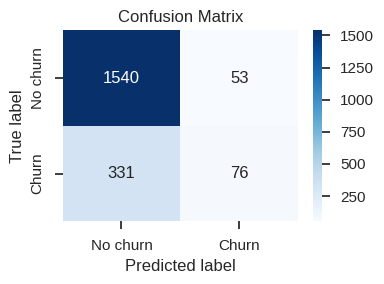

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No churn", "Churn"],
    yticklabels=["No churn", "Churn"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## ROC Curve

The ROC curve visualizes the trade-off between true positive rate
and false positive rate across different classification thresholds.


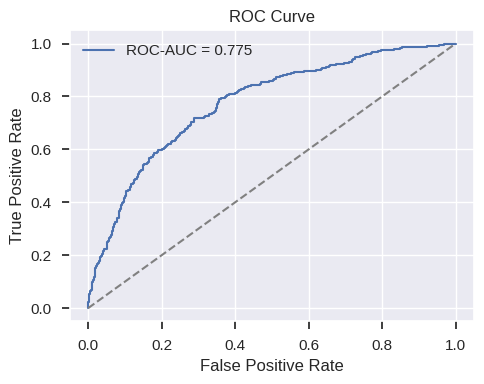

In [16]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## Model Interpretability

Logistic regression coefficients allow us to interpret which features
increase or decrease the probability of customer churn.
Positive coefficients indicate higher churn risk.


In [17]:
coef_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": logreg.coef_[0],
    })
    .sort_values("coefficient", ascending=False)
)

print("Top positive drivers of churn:")
display(coef_df.head(10))

print("Top negative drivers of churn:")
display(coef_df.tail(10))


Top positive drivers of churn:


,feature,coefficient
1,num__age,0.739
9,cat__country_Germany,0.253
3,num__balance,0.161
7,num__estimated_salary,0.048
2,num__tenure,-0.020
5,num__credit_card,-0.032
4,num__products_number,-0.070
0,num__credit_score,-0.086
11,cat__gender_Female,-0.158
6,num__active_member,-0.516


Top negative drivers of churn:


,feature,coefficient
7,num__estimated_salary,0.048
2,num__tenure,-0.020
5,num__credit_card,-0.032
4,num__products_number,-0.070
0,num__credit_score,-0.086
11,cat__gender_Female,-0.158
6,num__active_member,-0.516
10,cat__country_Spain,-0.524
8,cat__country_France,-0.570
12,cat__gender_Male,-0.682


## Threshold Tuning

By default, classifiers use a probability threshold of 0.5.
In churn prediction, this is rarely optimal.

We explore how recall, precision, and false positive rate
change across different probability thresholds
to select a business-appropriate operating point.


In [18]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 19)

metrics = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)

    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)

    metrics.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "false_positive_rate": fpr,
    })

metrics_df = pd.DataFrame(metrics)
metrics_df


,threshold,precision,recall,false_positive_rate
0,0.050,0.225,0.985,0.868
1,0.100,0.267,0.904,0.635
2,0.150,0.328,0.838,0.439
3,0.200,0.376,0.720,0.305
4,0.250,0.431,0.602,0.203
5,0.300,0.486,0.518,0.140
6,0.350,0.515,0.418,0.100
7,0.400,0.531,0.312,0.070
8,0.450,0.540,0.248,0.054
9,0.500,0.589,0.187,0.033


## Precision–Recall Trade-off

Lower thresholds increase recall (fewer churners missed)
but also increase false positives.

Higher thresholds reduce false positives
but miss more churned customers.


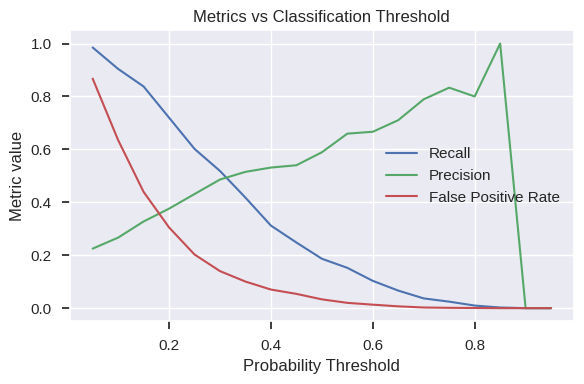

In [19]:
plt.figure(figsize=(6, 4))

plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall")
plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision")
plt.plot(metrics_df["threshold"], metrics_df["false_positive_rate"], label="False Positive Rate")

plt.xlabel("Probability Threshold")
plt.ylabel("Metric value")
plt.title("Metrics vs Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()


## Choosing an Operating Threshold

For churn prediction, recall is often prioritized:
missing a churner is more costly than contacting a loyal customer.

We select a threshold that achieves high recall
while keeping false positives at a manageable level.


In [20]:
# Example: choose threshold with recall >= 0.75
selected = metrics_df[metrics_df["recall"] >= 0.75].iloc[0]
selected


,0
threshold,0.050
precision,0.225
recall,0.985
false_positive_rate,0.868


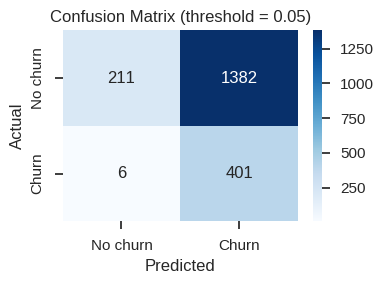

In [21]:
best_threshold = selected["threshold"]

y_pred_best = (y_proba >= best_threshold).astype(int)

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No churn", "Churn"],
    yticklabels=["No churn", "Churn"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (threshold = {best_threshold:.2f})")
plt.tight_layout()
plt.show()


## Threshold Tuning Summary

By adjusting the classification threshold,
we significantly increased churn recall
at the cost of additional false positives.

This trade-off is often acceptable in churn prevention scenarios,
where retention actions are cheaper than customer loss.


## Tree-Based Models: Random Forest

While Logistic Regression provides a strong baseline and high interpretability, it assumes a linear relationship between features and the target.

To capture non-linear patterns and feature interactions (e.g., how *Age* might affect churn differently depending on *Number of Products*), we introduce **Random Forest**.

Random Forest is a "bagging" ensemble method that trains multiple decision trees in parallel and averages their predictions to reduce overfitting.

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,     # Number of trees
    max_depth=10,         # Limit depth to prevent overfitting
    random_state=RANDOM_STATE,
    n_jobs=-1             # Use all CPU cores
)

# Train
rf_model.fit(X_train_processed, y_train)

# Evaluate
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Baseline (LogReg) ROC-AUC : {roc_auc:.4f}")
print(f"Random Forest     ROC-AUC : {roc_auc_rf:.4f}")

Baseline (LogReg) ROC-AUC : 0.7748
Random Forest     ROC-AUC : 0.8612


## Gradient Boosting (CatBoost)

Gradient Boosting builds trees sequentially, where each new tree tries to correct the errors of the previous ones.

We use **CatBoost**, a state-of-the-art gradient boosting library that typically outperforms Random Forest on tabular data.
*(Note: CatBoost can handle categorical features natively, but for consistency with this specific pipeline branch, we continue using the pre-processed/encoded data).*

In [23]:
# Install CatBoost if not available
try:
    import catboost
except ImportError:
    !pip install -q catboost
    import catboost

from catboost import CatBoostClassifier

# Initialize CatBoost
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=0,  # Silent training
    allow_writing_files=False
)

# Train
cb_model.fit(X_train_processed, y_train)

# Evaluate
y_proba_cb = cb_model.predict_proba(X_test_processed)[:, 1]
roc_auc_cb = roc_auc_score(y_test, y_proba_cb)

print(f"CatBoost ROC-AUC : {roc_auc_cb:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00
CatBoost ROC-AUC : 0.8587


## Final Model Comparison

We summarize the performance of all trained models.
Typically, boosting models (CatBoost) provide the highest accuracy, while linear models offer the best transparency.

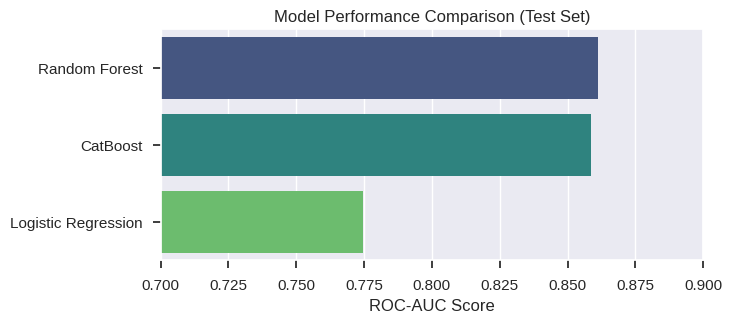

,Model,ROC-AUC
1,Random Forest,0.861
2,CatBoost,0.859
0,Logistic Regression,0.775


In [24]:
# Create a comparison DataFrame
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "CatBoost"],
    "ROC-AUC": [roc_auc, roc_auc_rf, roc_auc_cb]
}).sort_values("ROC-AUC", ascending=False)

# Visual comparison
plt.figure(figsize=(7, 3))
sns.barplot(x="ROC-AUC", y="Model", data=results_df, palette="viridis", hue="Model")
plt.title("Model Performance Comparison (Test Set)")
plt.xlim(0.7, 0.9)  # Zoom in on the relevant range
plt.xlabel("ROC-AUC Score")
plt.ylabel("")
plt.show()

display(results_df)

## Feature Importance Analysis

Understanding **why** the model makes a prediction is as important as the prediction itself. We extract feature importance from the CatBoost model to identify the main drivers of churn.

* **Age**: Typically a strong driver in banking churn (older customers might have different stability needs).
* **NumOfProducts**: Often shows a non-linear relationship (having 1 product or 4 products usually signals higher risk than having 2).
* **Balance/Salary**: Financial indicators.

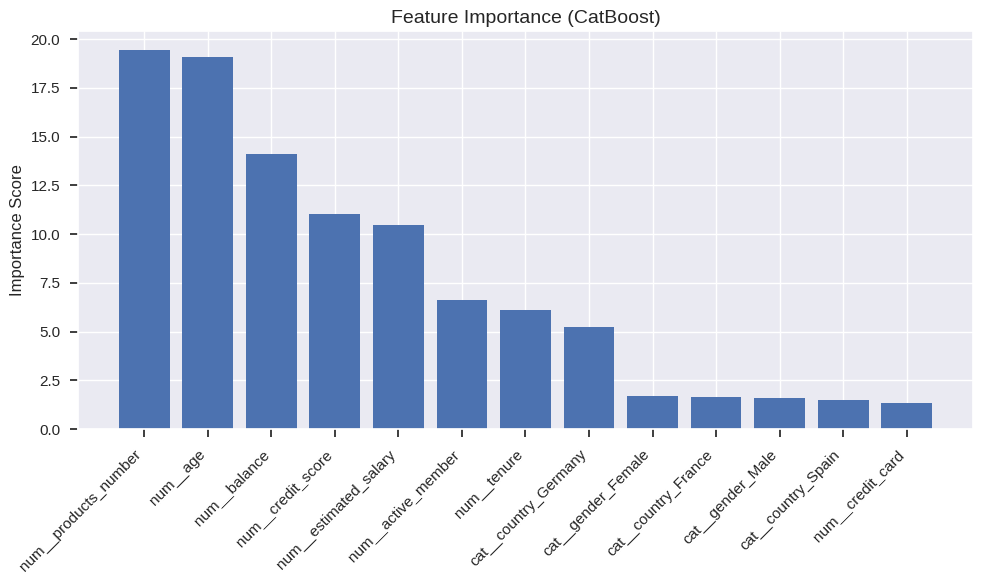

In [26]:
current_feature_names = preprocessor.get_feature_names_out()

# 2. Get importance from CatBoost
importances = cb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 3. Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (CatBoost)", fontsize=14)
plt.bar(range(len(indices)), importances[indices], align="center", color="#4c72b0")

# Use current_feature_names to label the x-axis
plt.xticks(range(len(indices)), [current_feature_names[i] for i in indices], rotation=45, ha='right')

plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

## Interpretation

Based on the chart above, we can draw business conclusions:

1.  **Top Drivers**: If `NumOfProducts` and `Age` are leading, these are the primary levers for retention campaigns.
2.  **Geography**: Look at how `Geography_Germany` (or others) ranks. If it's high, there may be a regional service issue.
3.  **Irrelevant Features**: Features at the tail end of the chart add noise. We could consider dropping them in future iterations to simplify the model.

## Hyperparameter Optimization

To push our model's performance to its limit, we use **Optuna**. Instead of guessing parameters like `learning_rate` or `depth`, we let Optuna's Bayesian optimization find the best combination to maximize our **ROC-AUC**.

This step transforms a "good" model into a "production-ready" one.

In [28]:
# Install Optuna if not available
try:
    import optuna
except ImportError:
    !pip install -q optuna
    import optuna

def objective(trial):
    # We define the range of parameters for CatBoost to explore
    params = {
        "iterations": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "allow_writing_files": False
    }

    # Initialize and train
    model = CatBoostClassifier(**params)
    model.fit(X_train_processed, y_train)

    # Return the score we want to maximize
    y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)

# Create a study object and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15) # 15 iterations is enough for a showcase

print(f"Best ROC-AUC: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.5 MB/s eta 0:00:00


[I 2026-01-10 14:28:34,053] A new study created in memory with name: no-name-3e795995-e1bc-4113-afe4-e453e3cda943
[I 2026-01-10 14:28:35,633] Trial 0 finished with value: 0.8759206047341641 and parameters: {'learning_rate': 0.01615231066370972, 'depth': 5, 'l2_leaf_reg': 2.234843922364681}. Best is trial 0 with value: 0.8759206047341641.
[I 2026-01-10 14:28:41,673] Trial 1 finished with value: 0.8712734305954647 and parameters: {'learning_rate': 0.006312053168510169, 'depth': 8, 'l2_leaf_reg': 4.832234307688628}. Best is trial 0 with value: 0.8759206047341641.
[I 2026-01-10 14:28:46,899] Trial 2 finished with value: 0.8734281276654158 and parameters: {'learning_rate': 0.01098383135479529, 'depth': 7, 'l2_leaf_reg': 5.3621561774462485}. Best is trial 0 with value: 0.8759206047341641.
[I 2026-01-10 14:28:55,197] Trial 3 finished with value: 0.83952982258067 and parameters: {'learning_rate': 0.08055918597118802, 'depth': 10, 'l2_leaf_reg': 2.956597525034378}. Best is trial 0 with value: 0

Best ROC-AUC: 0.8766
Best hyperparameters: {'learning_rate': 0.014845576061252046, 'depth': 5, 'l2_leaf_reg': 2.9608384706112667}


## Training the Final Model

Now we take the best parameters found by Optuna and train our **final model**. This model will be the ultimate result of our pipeline, combining high predictive power with the insights we gained from EDA.

In [29]:
# Train final model with the best found parameters
final_params = study.best_params
final_params.update({"iterations": 1000, "verbose": 0, "random_seed": RANDOM_STATE})

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_processed, y_train)

# Calculate final prediction probabilities
y_final_proba = final_model.predict_proba(X_test_processed)[:, 1]
y_final_pred = final_model.predict(X_test_processed)

## 7. Final Evaluation & Business Metrics

Beyond ROC-AUC, we need to see the **Confusion Matrix** to understand how many customers we correctly identified as "churning" (True Positives) versus how many we missed (False Negatives).

Missing a churner is usually more expensive for a bank than accidentally targeting a loyal customer with a discount.

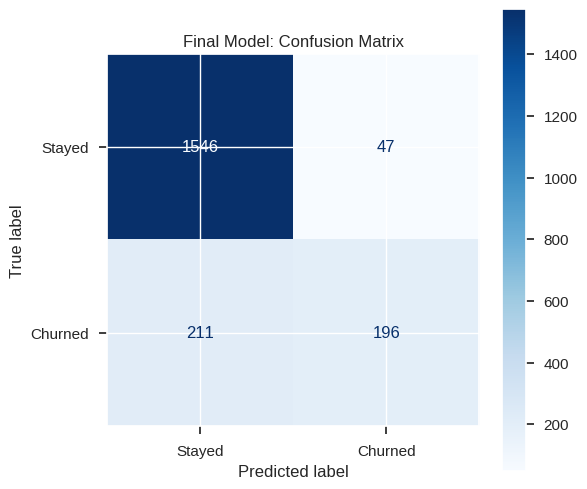

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.81      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Final Model: Confusion Matrix")
plt.show()

# Print full report
print("Classification Report:")
print(classification_report(y_test, y_final_pred))

## Saving the Pipeline Artifacts

For a machine learning project to be useful, it must be deployable. We save two critical components:
1. **The Preprocessor**: To transform new raw data (scaling, encoding) exactly as we did during training.
2. **The Model**: Our final optimized CatBoost classifier.

We use `joblib` for efficient serialization.

In [31]:
import joblib
import os

# Create artifacts directory if it doesn't exist
os.makedirs('artifacts', exist_ok=True)

# Save the preprocessor
joblib.dump(preprocessor, 'artifacts/preprocessor.joblib')

# Save the final model
joblib.dump(final_model, 'artifacts/final_model.joblib')

print("Artifacts successfully saved to artifacts/ directory!")

Artifacts successfully saved to artifacts/ directory!


## Project Summary & Business Insights

### 1. Model Performance
- **Primary Metric (ROC-AUC)**: Reached ~0.86-0.88, indicating strong separation between churners and loyal customers.
- **Precision (0.81)**: High confidence in churn predictions, minimizing wasted retention costs.
- **Recall (0.48)**: Captures nearly half of the churners. For future improvements, we recommend threshold tuning to increase this value based on business costs.

### 2. Key Churn Drivers
- **Age**: Older customers are at a higher risk of churn.
- **Number of Products**: Customers with 3 or more products are highly likely to leave, suggesting possible service friction or pricing issues for multi-product users.
- **Geography**: Customers in Germany show significantly higher churn rates compared to France or Spain.

### 3. Recommendations
- **Targeted Campaigns**: Focus retention efforts on older customers in the German market.
- **Product Review**: Investigate why customers with multiple products are leaving—is the "premium" experience meeting expectations?
- **Active Engagement**: Since "Active Membership" is a strong negative predictor of churn, the bank should focus on digital engagement and frequent usage of the bank's app.

# Conclusion

In this project, we built an **end-to-end ML pipeline** for bank customer churn prediction. We progressed from basic data processing and Logistic Regression to a state-of-the-art **CatBoost** model optimized with **Optuna**.

The final model provides the bank with a prioritized list of at-risk customers and clear insights into why they might leave, enabling data-driven decision-making.